In [1]:
#dependency
import time
import qmcpy
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.lax as lax
from jax import grad, jit
import optax
from qmcpy import Halton
from qmcpy import Lattice
from qmcpy import Sobol
import itertools







# Visual Utilities------------------------------------

def plot2DArrow(init, end, Ax = None, paint = 'blue'):
    if Ax is None:
        Ax = plt.gca()
    dx = end[:,0] - init[:,0]
    dy = end[:,1] - init[:,1]
    Ax.quiver(init[:,0], init[:,1], dx, dy, angles='xy', scale_units='xy', scale = 1, color = paint , width=0.003)
    Ax.legend()
    plt.show()
    return Ax

def locdisc(x, y, points):
    no = 0
    nc = 0
    n = len(points)
    for i in range(n):
        if points[i][0] < x and points[i][1] < y:
            no += 1
        if points[i][0] <= x and points[i][1] <= y:
            nc += 1
    return max(x*y - no/n, nc/n - x*y)


def heatmap_from_array(points, Ax=None):
    n = len(points)
    PX = points[:, 0]
    PY = points[:, 1]

    X = [0.001 * i for i in range(1001)]
    Y = [0.001 * i for i in range(1001)]
    Z = [[0 for _ in range(1001)] for _ in range(1001)]

    maxi = 0
    mxii = 0
    mxjj = 0
    for i in range(1001):
        for j in range(1001):
            Z[j][i] = locdisc(X[i], Y[j], points)
            if Z[j][i] > maxi:
                maxi = Z[j][i]
                mxii = i
                mxjj = j

    if Ax is None:
        Fig, Ax = plt.subplots(figsize=(7, 6))

    cs = Ax.contourf(X, Y, Z, levels=40, cmap= "viridis")
    plt.colorbar(cs, ax = Ax, label= "Local Discrepancy")
    Ax.scatter(PX, PY, c='r', s=50, linewidth=1, alpha=0.7)
    Ax.scatter(mxii/1000, mxjj/1000, c='black')
    Ax.set_xlabel("x")
    Ax.set_ylabel("y")
    Ax.set_aspect('equal')

    return Ax, maxi


def draw_history(hist, title = "History", label = "L2", xlabel = "Iteration", ylabel = "Discrepancy", Ax = None):
    if Ax is None:
        Fig = plt.figure(figsize=(8, 5))
        Ax = Fig.gca()
    
    Ax.plot(hist, label= label, color = 'blue')
    Ax.set_xlabel(xlabel)
    Ax.set_ylabel(ylabel)
    Ax.set_title(title)
    Ax.legend()
    Ax.grid(True)
    plt.tight_layout()
    plt.show()
    
    return Ax


def draw_the_plot(initial, optimized, 
                  title = "Summary", label1 = "Initial", label2 = "Optimized", arrow = True, Ax = None):
        
    if Ax is None:
        Fig = plt.figure(figsize=(6, 6))
        Ax = Fig.gca()
        
    ip = initial
    fp = optimized
    Ax.scatter(ip[:, 0], ip[:, 1], c ='red', label=label1)
    Ax.scatter(fp[:, 0], fp[:, 1], c ='green', label=label2)

    if arrow: plot2DArrow(ip, fp, Ax = Ax, paint = 'blue')
    Ax.set_title(title)
    Ax.set_aspect('equal')

    Ax.set_xlim(0, 1)
    Ax.set_ylim(0, 1)
    Ax.grid(True)
    Ax.legend()
    plt.tight_layout()
    plt.show()
        
    return Ax


def draw_heatmap(points, title = "Heatmap", Ax = None):
    if Ax is None:
        Fig = plt.figure(figsize = (7, 5))
        Ax = Fig.gca()

    # Heatmap for initial set
    _, max_init = heatmap_from_array(points, Ax=Ax)
    Ax.set_title(title)
    Ax.text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
        transform= Ax.transAxes, ha='center', fontsize=11)        
    plt.tight_layout()
    plt.show()
    return Ax

# Functional Utilities------------------------------------

def smooth_max(a, b, tau=1e-4):
    '''
    Smoothened maximum function. Control tau to adjust accuracy.
    '''
    return 0.5 * (a + b + ((a - b)**2 + tau)**(0.5))


def internalize(points):
    '''
    #Args
    point set,
    
    #returns

    the sorted version of each coordinate, (sortedCoordinates)
    and the order indices in which coordinates of each point appears in the sortedCoordinates, (ordidx)
    '''
    d = points.shape[1]
    n = points.shape[0]
    sortedCoordinates = np.apply_along_axis(sorted, axis = 0, arr = points).T
    sortedIndices = np.argsort(points, axis = 0)
    ordidx = np.empty_like(sortedIndices)
    for j in range(d):
        ordidx[sortedIndices[:, j], j] = np.arange(n)     

    return sortedCoordinates, ordidx




def L2Disc(points, smoothing = False, tau = 1e-16):
    
    '''
    L2 Discrepancy, following the Wornock's formula. Written in Numpy setting.
    '''
    n = points.shape[0]
    d = points.shape[1]

    SP1 = jnp.sum(jnp.prod(1 - points**2, axis=1))
    
    x_i = points[:, jnp.newaxis, :]  # shape: (n, 1, d)
    x_j = points[jnp.newaxis, :, :]  # shape: (1, n, d)


    vf_values = lax.cond(
    smoothing,
    lambda _: smooth_max(x_i, x_j, tau=tau),
    lambda _: jnp.maximum(x_i, x_j),
    operand=None
    )

    SP2 = jnp.sum(jnp.prod(1 - vf_values, axis=2))

    return 1/(3**d) - 2**(1-d)/n * SP1 + 1/(n**2) * SP2


def LinfDisc(points, sizelim = 300**2, mg_size = 300, method = 'meshgrid'):
    '''
    L - Inf Discrepancy by definition.
    '''
    n = points.shape[0]
    d = points.shape[1]

    #size control
    size_est = n**d
    if size_est > sizelim:
        method = 'meshgrid'        
    #Internalize <- recommended for small sized point set
    if method == 'internalize':
        #sortedCoordinate, ordidx = funcUtils.internalize(points)
        disc = 0.0
        points = jnp.vstack((points, jnp.ones(d)))
        for item in itertools.product(*points.T):
            gridix = jnp.array(item)
            vol = jnp.prod(gridix)
            #print(vol)
            opencount =  jnp.sum(jnp.all(points < gridix, axis=1))
            closedcount =  jnp.sum(jnp.all(points <= gridix, axis=1))
            disc = max(disc, closedcount/n - vol, vol - opencount/n)
        return disc
        
    #Meshgrid <- recommended for relatively large sized point set. Vectorized operations.
    elif method == 'meshgrid':
       dims = [jnp.linspace(0, 1, mg_size) for _ in range(d)]
       grid = jnp.meshgrid(*dims, indexing='xy')
       reshape_grid = jnp.array(grid).reshape(len(grid), -1)
       eval_set = jnp.stack(reshape_grid, axis = 1)
       #print(eval_set.shape)
       comparison = points[jnp.newaxis, :, :] < eval_set[:, jnp.newaxis, :]
       count = jnp.sum(jnp.all(comparison, axis=2), axis=1)
       disc = jnp.max(jnp.abs(count/n - jnp.prod(eval_set, axis = 1)))
       return disc



def PeriodicL2Disc(points, smoothing = False):
    '''
    Periodic L2 Discrepancy, following the Wornock's formula. Written in Numpy setting.
    '''
    pass

def ExtremeL2Disc(points, smoothing = False):
    '''
    Extreme L2 Discrepancy, following the Wornock's formula. Written in Numpy setting.
    '''
    pass

def unitCubeProj(points):
    return jnp.clip(points, 0.0, 1.0)


L2 = lambda points: L2Disc(points, smoothing = False)
L2_Smooth = lambda points: L2Disc(points, smoothing = True)
PeriodicL2 = lambda points: PeriodicL2Disc(points, smoothing = False)
PeriodicL2_Smooth = lambda points: PeriodicL2Disc(points, smoothing = True)
ExtremeL2 = lambda points: ExtremeL2Disc(points, smoothing = False)
ExtremeL2_Smooth = lambda points: ExtremeL2Disc(points, smoothing = True)
Linf = lambda points : LinfDisc(points, sizelim = 300**2, mg_size = 300, method = 'meshgrid')


# Sequence Generators ------------------------------------

def getKronecker(n, phi, placehold = 0, startwith = 0):
    '''
    Generates Kronecker lattice.

    #Args

    n : number of points to sample
    Phi : d - 1 dimensional real vector whose coordinates are linearly independent over rationals
    placehold : the coordinate of lattice that will be linearly increasing.
    startwith : the starting index to be scaled by Phi.

    #returns
    A Kronecker lattice.
    '''
    if jnp.isscalar(phi):
        phi = jnp.array([phi])
        
    d = phi.shape[0]+1
    i_values = jnp.arange(startwith, n + startwith).reshape(n, 1)
    scaled_phi = (i_values * phi) % 1
    points = jnp.zeros((n, d))
    idx = list(range(d))
    idx.pop(placehold)
    points = points.at[:, idx].set(scaled_phi)
    points = points.at[:, placehold].set(jnp.arange(startwith, n + startwith) / n)

    return points

    
def getFibonacci(n, d = 2, placehold = 0):
    '''
    Generates first n terms of the fibonacci sequence. Currently 2 - dimensional only
    '''
    phi_1 = (jnp.sqrt(5) - 1)/2
    phi = jnp.array([ (phi_1**j - 1)/(phi_1 -1) for j in range(2,d+1)])
    return getKronecker(n, phi = phi, placehold = placehold, startwith = 0)


def getHalton(n, d = 2):
    HaltonGenerator = Halton(dimension=d)
    return HaltonGenerator.gen_samples(n)


def getRandom(n, d = 2):
    return np.random.rand(n,d)
    

def getSobol(n, d, randomnize = 'LMS_DS', seed = None):
    '''
    Works properly only when n is a power of 2.
    '''
    Sob = Sobol(dimension=d, randomize = randomnize, seed = seed)
    return Sob.gen_samples(n)

def getLattice(n,d, randomnize = 'shift', order = 'natural', seed = None):
    '''
    Works properly only when n is a power of 2.
    '''
    l = Lattice(dimension=d, randomize = randomnize, order = order, seed = seed)
    return l.gen_samples(n)


def getMPMC(n, d = 2):
    pass

def default_compute_additionals(**kwargs):
    return {}

class OptTester:
    '''
    A Wrapper class for optax optimizer that is *iterative, and *use gradient.
    This class helps running various optimizers, options, and experiments for optimization task of discrepancies,
    easily for who are aware of basics of optax, without need of duplication of codes.
    Design of this class sticks to functional programming paradigm.
    '''
    linf = Linf
    l2 = L2

    
    def __init__(self, optimizer, name = "",
                 compute_additionals = default_compute_additionals, dec = lambda x: unitCubeProj(x), enc = lambda x : x):
        '''
        Initializer of class OptTester.
        #Args

        optimizer : optax optimizer object. 
        name : string.

        compute_additionals : 
        A function returning dictionary of keyword arguments and value pair,
        out of gradient, value, current parameter state, and loss function, plus some extra arguments (if needed)
        The signature of compute_additionals should be formatted like the beow:

        def compute_additionals(grad = None, val = None, state = None, lossfn = None, **args):
            ... ...
            return {'karg1' : v1, 'karg2' : v2, ...}
        
        where 'karg1','karg2',... are keyword arguments needed for self.optimizer.update()
        

        enc, dec: A function taking a point set and returning a point set. Performed before and after each step of iterative optimization.
        For example, dec is by default an action of cliping points in [0,1].  
        '''
        self.optimizer = optimizer
        self.name = name
        self._compute_additionals = compute_additionals
        self._dec = dec
        self._enc = enc


    def step(self, state, lossfn, opt_state, extra = None):
        '''
        Perform one step of iterative optimization.

        #Args
        state : parameters to optimize. lossfn : jax - differentiable loss function to optimize. 
        opt_state : optimizer state. 
        extra : extra arguments needed for self.optimizer.update(), other than gradient, value, parameters and loss function.

        #returns
        A tuple of updated state(parameters) and an updated optimizer state.
        '''
        if opt_state is None:
            raise Exception("Not properly initialized")
        
        if extra is None:
            extra = {}
        
        state = self._enc(state)
        
        loss_and_grad = jax.value_and_grad(lossfn)
        lfvalue, lfgrad = loss_and_grad(state)

        additionals = self._compute_additionals(**{'grad':lfgrad, 'val':lfvalue, 'state':state, 'lossfn':lossfn, **extra})

        updates, opt_state = self.optimizer.update(lfgrad, opt_state, params = state, **additionals)
        state = optax.apply_updates(state, updates)
        
        state = self._dec(state)
    
        return state, opt_state


    @property
    def dec(self): return self._dec
    @property
    def enc(self): return self._enc
    @property
    def compute_additionals(self): return self.compute_additionals
    @dec.setter
    def dec(self, dec1): self._dec = dec1
    @enc.setter
    def enc(self, enc1): self._enc = enc1
    @compute_additionals.setter
    def compute_additionals(self, func): self._compute_additionals = func
    @classmethod
    def set_LInf(cls, linf):
        cls.Linf = linf
    
    @classmethod
    def set_L2(cls, l2):
        cls.L2 = l2




    def iterate(self, init_data, lossfn, maxiter = 200, tol = 1e-6,
            linf_record_step = 1, save_history = False, L2 = l2, Summary = True):
        '''
        Perform whole iterative optimization.
        #Args

        init_data : points to optimize. 
        lossfn : jax - differentiable loss function to optimize.
        maxiter : maximum number of iteration.
        tol : tolerance to be used for break condition.

        linf_record_step : integer referring how frequently evalute L_infinity discrepancy. For example, if 2, it evaluates per every 2 steps.
        Helpful for fast execution because L_infinity discrepancy is computationally heavy, especially for higher dimensions.

        save_history : bool flag to save histories or not. Helpful for fast execution as well.

        L2 : A reference function to record history. This is needed because L2 discrepancy is nonsmooth.
        As well as lossfn, one can give different versions (Periodic, Extreme) discrepancies.

        Summary : A bool flag. If True, displays decadance of loss function, and print out the summary of optimization.

        #returns
        tuple of optimized points, history of L2, history of L_infinity discrepancy. histories are meaningful only if save_history = True.
        '''
        #initialization
        inum = 0
        opt_state = self.optimizer.init(init_data)
        state = init_data
        
        #initialization of result lists
        LInf_history = [OptTester.linf(state)]
        Loss_history = [lossfn(state)]
        history = []

        if L2 is None: history = [lossfn(state)] 
        else: history =  [L2(state)]


        while inum < maxiter:
            before_step = state
            #functional control of loss func
            state, opt_state = self.step(state, lossfn, opt_state)
            Loss_history.append(lossfn(state))

            if save_history:
                if L2 is None: history.append(lossfn(state))
                else: history.append(L2(state))
                # Since LInf is computationally heavy, one can compute it less frequently
                if inum % linf_record_step == 0: LInf_history.append(OptTester.linf(state))
                  
            inum +=1

            #stop condition if tolerance gap is achieved
            if jnp.linalg.norm(state - before_step) < tol: break
    
        LInf_history.append(OptTester.linf(state))

        #summary
        if Summary:
            draw_history(Loss_history, title = self.name, label = "lf", xlabel = "Iteration", ylabel = "Loss", Ax = None)
            # === Output ===
            print("Initial L2 discrepancy:", L2(init_data))
            print("Final L2 discrepancy value:", L2(state))
            print("Optimized Points:\n", state)

        return state, history, LInf_history




# General Utilities------------------------------------

def timeit(func):
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()  # More precise than time.time()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        print(f"Function '{func.__name__}' executed in {end_time - start_time:.6f} seconds")
        return result
    return wrapper


def visualize_all(init, optimized, *histories):
    '''
    Perform all the relevant plots. It is combination of draw_the_plot, draw_heatmap, draw_history.
    '''
    Ax1 = draw_the_plot(init, optimized, arrow = True)
    Ax2 = draw_heatmap(optimized)
    Axs = []
    i = 1
    for hist in histories:
        Axs.append(draw_history(hist, label = "history #"+str(i)))
        i +=1

    return Ax1, Ax2, tuple(Axs)


def random_restart(opttester, init_data, lossfn, scale = 0.2, restart_num = 10):
    '''
    Perform iterations of given optimizer, by random restarting #restart_num times.

    #Args
    
    opttester : OptTester.
    init_data : points to optimize.
    lossfn : jax - differentiable loss function to optimizer. 
    scale : magnitude of added random noise. 
    restart_num : number of repetition.
    
    #returns
    final optimized points, total history of L2 discrepancy, total history of L_inf discrepancy
    '''
    data = init_data
    concat_L2hist = []
    concat_Linfhist = []
    key = jax.random.key(42)

    for i in range(restart_num):
        key, subkey = jax.random.split(key)
        data, L2hist, Linfhist, = opttester.iterate(data, lossfn, linf_record_step = 15, save_history = True, Summary = False)
        noise = scale * (jax.random.uniform(key, shape=data.shape) - 0.5) * 2
        data = unitCubeProj(data + noise)
        
        concat_L2hist = concat_L2hist + L2hist
        concat_Linfhist = concat_Linfhist + Linfhist
    
    return data, concat_L2hist, concat_Linfhist




In [3]:
loss_fn = L2_Smooth

Sq320d2 = getKronecker(n = 20, phi = jnp.sqrt(3))
Fn20d2 = getFibonacci(n= 20, d = 2)
Sob32d2 = getSobol(n= 32, d = 2)
Hal20d2 = getHalton(n= 20, d = 2)
Lat32d2 = getLattice(n= 32, d = 2)

In [9]:
#Learning Rates and Schedules-------------------------------------------
'''
'''
learning_rate1 = 0.001
learning_rate_polynomial =  optax.polynomial_schedule(init_value= 0.001, end_value=0.0005, transition_steps = 100, power=2)
learning_rate_exponential = optax.exponential_decay(0.01, transition_steps = 15, decay_rate =0.8, transition_begin = 10) 

In [11]:
#Basic Optax optimizers--------------------------------------------------
'''
'''
Adamoptimizer = optax.adam(learning_rate1)
RMSpropOptimizer = optax.rmsprop(learning_rate=0.001)
SGDOptimizer = optax.sgd(learning_rate_polynomial)

In [13]:
#Chanining optax Optimizers----------------------------------------------
'''
'''
SGDBacktracker = optax.chain(
   optax.sgd(learning_rate= 0.1),
   optax.scale_by_backtracking_linesearch(max_backtracking_steps=15)
)

In [15]:
#Code example------------------------------------------------------------
Adamopt = OptTester(Adamoptimizer, name = "Adam")

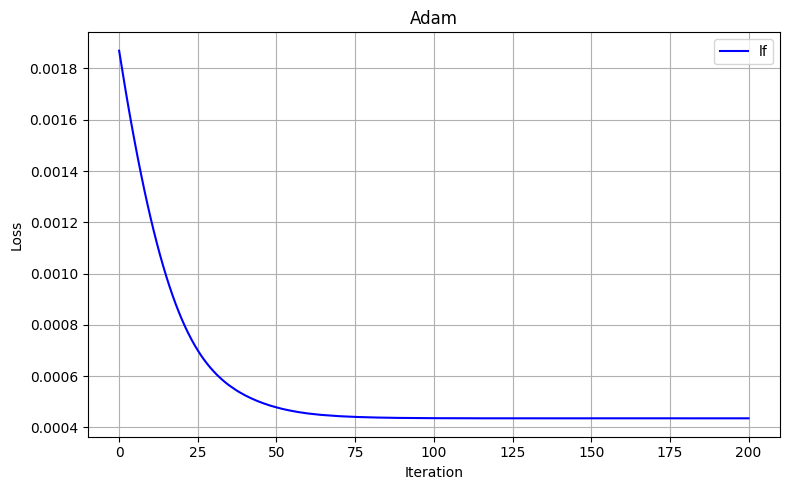

Initial L2 discrepancy: 0.0018693507
Final L2 discrepancy value: 0.00043524802
Optimized Points:
 [[0.0477251  0.04772511]
 [0.09112266 0.6461573 ]
 [0.15489721 0.29029143]
 [0.18699491 0.8717129 ]
 [0.23109974 0.49463606]
 [0.30407652 0.14997101]
 [0.34367064 0.7493588 ]
 [0.39843938 0.37840325]
 [0.43278357 0.96405584]
 [0.46396235 0.5792238 ]
 [0.52297324 0.21821143]
 [0.5724464  0.8129301 ]
 [0.61536103 0.43719026]
 [0.68285733 0.08913013]
 [0.7358709  0.69612753]
 [0.7918632  0.3272165 ]
 [0.8306126  0.9207525 ]
 [0.8653168  0.5393904 ]
 [0.9243793  0.1818845 ]
 [0.98064107 0.78257716]]


In [17]:
optimized_Fn20d2, L2hist, Linfhist = Adamopt.iterate(Fn20d2, loss_fn, linf_record_step = 10, save_history = True)

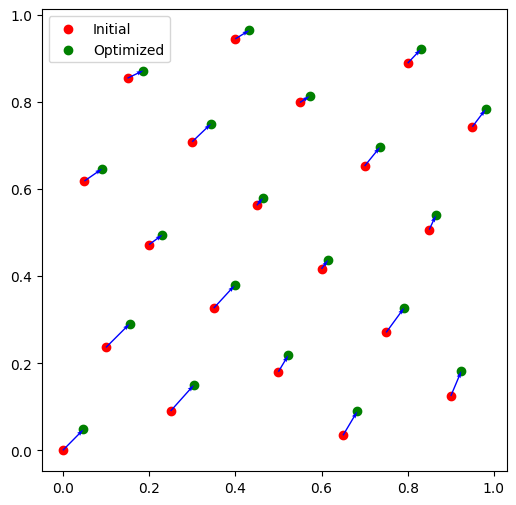

<Figure size 640x480 with 0 Axes>

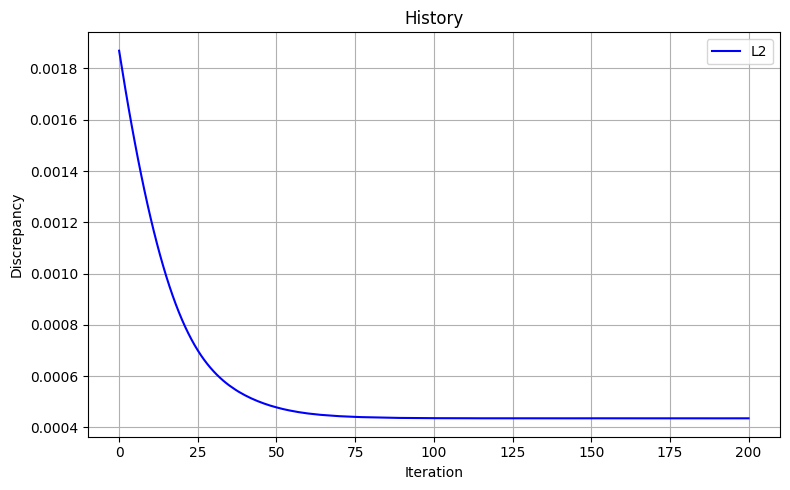

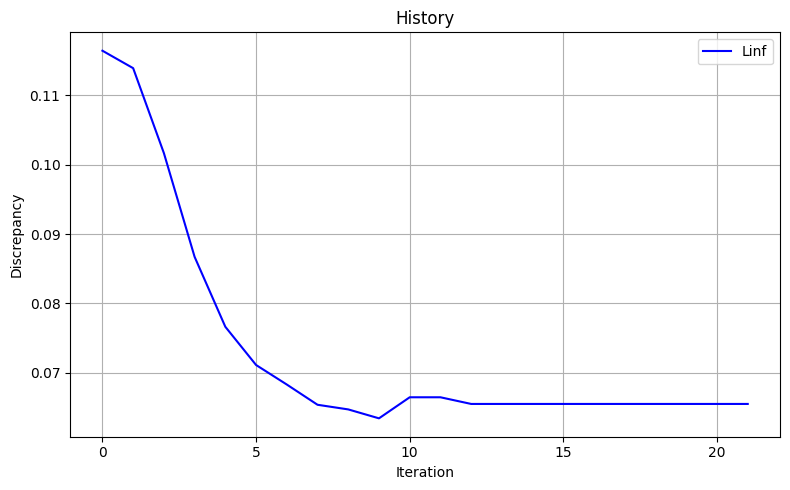

<Axes: title={'center': 'History'}, xlabel='Iteration', ylabel='Discrepancy'>

In [19]:
draw_the_plot(Fn20d2, optimized_Fn20d2, arrow = True)
draw_history(L2hist)
draw_history(Linfhist, label = "Linf")

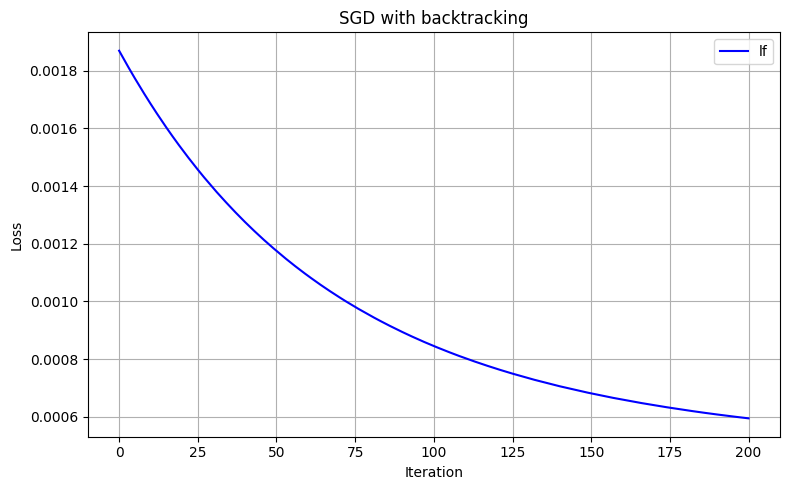

Initial L2 discrepancy: 0.0018693507
Final L2 discrepancy value: 0.00059423596
Optimized Points:
 [[0.03100925 0.03100926]
 [0.06864613 0.6466646 ]
 [0.1350017  0.27427655]
 [0.15790588 0.88020617]
 [0.21720234 0.49248856]
 [0.2881184  0.12805583]
 [0.31697127 0.7407569 ]
 [0.3817208  0.35980555]
 [0.40268815 0.9660114 ]
 [0.45916128 0.57478553]
 [0.5212509  0.20087925]
 [0.5571024  0.8121057 ]
 [0.6121752  0.4282822 ]
 [0.68334407 0.0577838 ]
 [0.7187238  0.67221576]
 [0.78511    0.29005215]
 [0.80690545 0.9014517 ]
 [0.86573064 0.5142999 ]
 [0.9344447  0.13257854]
 [0.9653363  0.74643004]]


In [27]:
def compute_additionals_backtracking(grad=None, val=None, state=None, lossfn=None, **args):
    return {'value': val, 'grad': grad, 'value_fn': lossfn}
SGD_Backtracking = OptTester(SGDBacktracker, name = "SGD with backtracking", compute_additionals = compute_additionals_backtracking)

SGD_optimized, SGD_l2hist, SGD_Linfhist = SGD_Backtracking.iterate(Fn20d2, loss_fn, linf_record_step = 10, save_history = True)

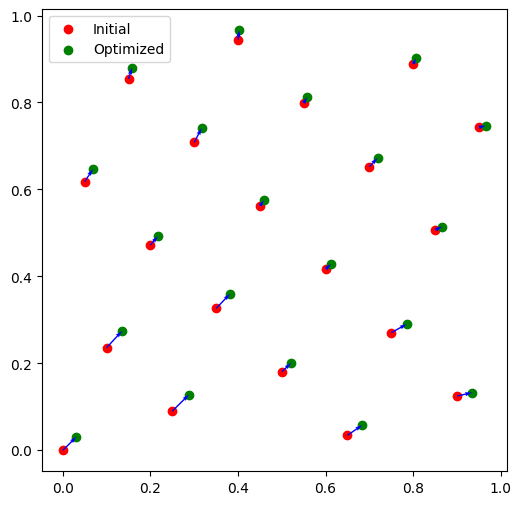

<Figure size 640x480 with 0 Axes>

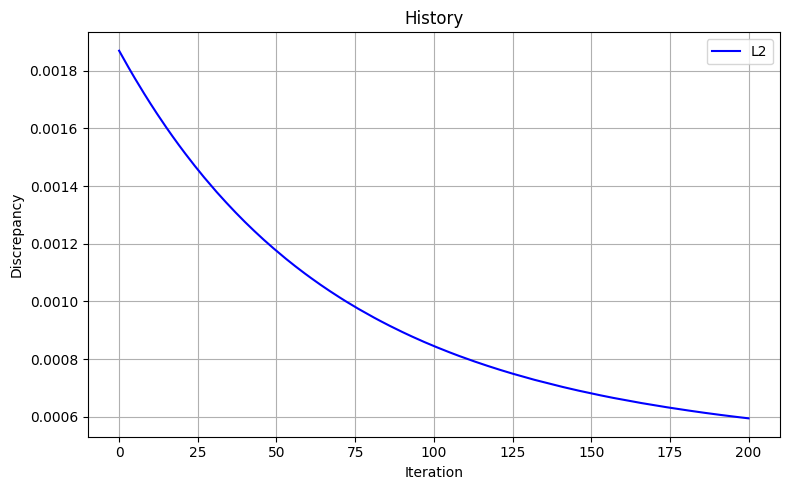

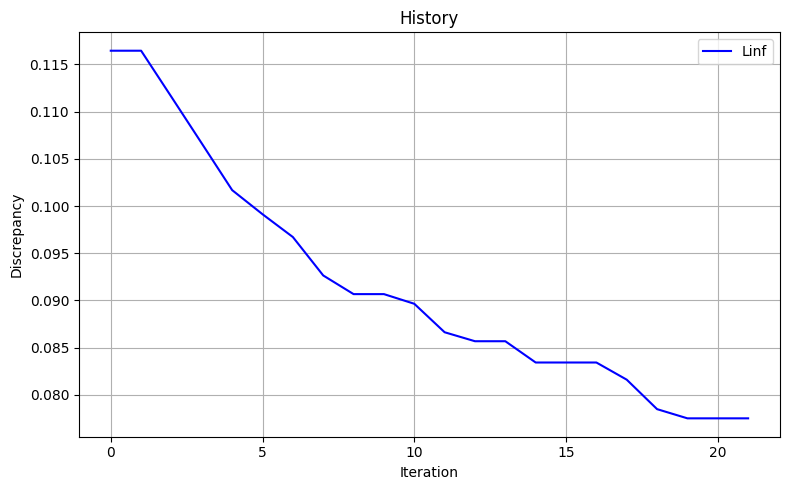

<Axes: title={'center': 'History'}, xlabel='Iteration', ylabel='Discrepancy'>

In [29]:
draw_the_plot(Fn20d2, SGD_optimized, arrow = True)
draw_history(SGD_l2hist) 
draw_history(SGD_Linfhist, label = "Linf")

In [5]:
Rnd20d2 = getRandom(n = 20,d = 2)
SGD = optax.sgd(learning_rate= 0.1)
SGDOpt = OptTester(SGD, name = "SGD")

RR_optimized, RR_l2hist, RR_Linfhist = random_restart(SGDOpt, Rnd20d2, loss_fn, scale = 0.02, restart_num = 5)

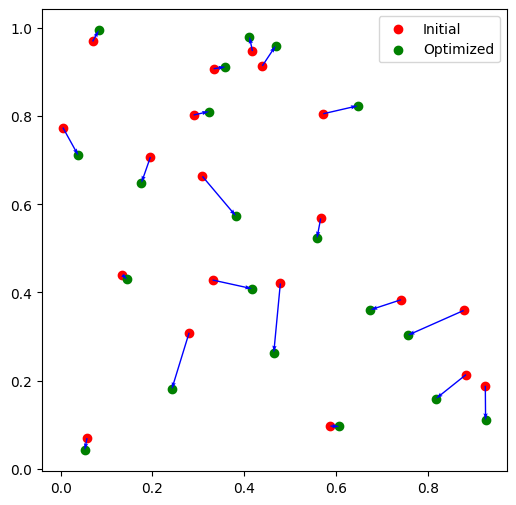

<Figure size 640x480 with 0 Axes>

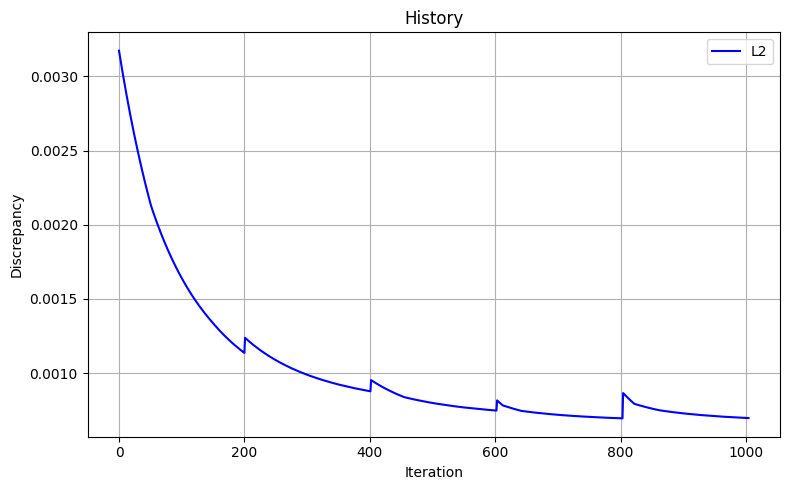

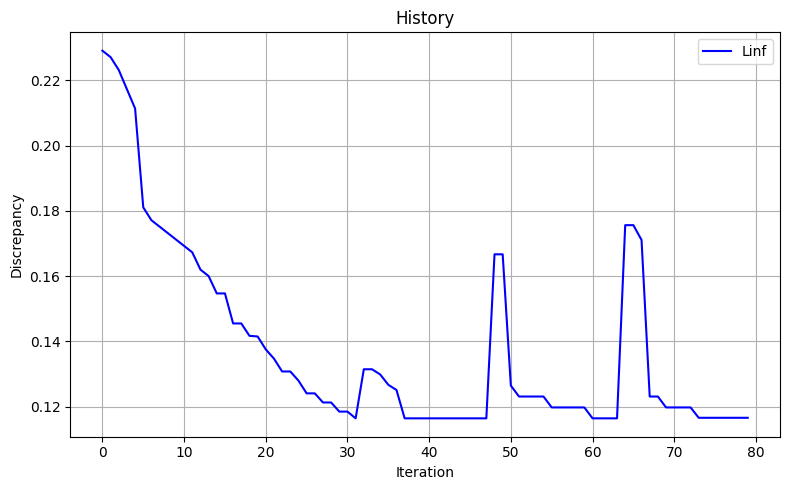

<Axes: title={'center': 'History'}, xlabel='Iteration', ylabel='Discrepancy'>

In [7]:
draw_the_plot(Rnd20d2, RR_optimized, arrow = True)
draw_history(RR_l2hist) 
draw_history(RR_Linfhist, label = "Linf")